# "Is anything wrong anywhere?" — detecting a few anomalies among thousands of streams

## The problem

A payments company watches 4,000 merchant-level fraud rates. A hospital network monitors 4,000
lab-result KPIs. A factory reads 4,000 sensors. A neuroscientist tracks 4,000 voxels. In all of these
a handful of streams may drift while the rest stay normal, and two different questions arise:

* **Which streams are off?** That is multiple testing — `e_bh` (false discovery rate) or
  `e_bonferroni` (family-wise error) in the parallel engine.
* **Is anything off at all?** That is a **global null** test — one alarm for the whole system, the
  thing an on-call engineer or a compliance officer actually wants first.

## Why the obvious global test fails

The engine's existing global merge takes the **arithmetic mean** of all 4,000 e-values. It is valid
under *any* dependence between streams, which is a great property, but it is powerless in exactly the
situation that matters: eight streams with strong evidence, averaged with 3,992 innocent ones, is a
small number. The sparse-mixture merge of Pérez-Ortiz, Castro & Stoepker (2025) instead asks
"what if some unknown small fraction of streams is anomalous?" and mixes over that fraction. It is
powerful precisely for *few strong* signals, at the price of requiring the streams to be
independent (if they are not, fall back to the mean).

## How it works

Each stream runs its own e-process in the Rust engine. At every time step we hand the *current*
per-stream values to `SparseMixtureMerger`, which returns a single global e-process value. Reject
when its running maximum reaches `1/alpha`. The merger also tells you what sparsity level the data
support and which streams carry the evidence — a ready-made triage list.

## Glossary

* **e-process**: capital of a bet against one stream's null, tracked over time; ≥ 1/alpha = alarm.
* **global null**: "every stream is normal".
* **sparsity `eps`**: the fraction of streams assumed anomalous; the merge mixes over a grid of values.
* **detection moment**: the time before which *no* method can detect the anomalies and after which
  this one does — a hard physical limit, not a tuning artefact.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from expectation.par_seqtest import ParallelSequentialTest, ParallelTestConfig
from expectation.modules.merging import ArithmeticMeanMerger, SparseMixtureMerger, detection_boundary

rng = np.random.default_rng(7)
K, ALPHA, T = 4000, 0.05, 120
n_anomalous, shift = 8, 0.5
anomalous = np.zeros(K, dtype=bool); anomalous[rng.choice(K, n_anomalous, replace=False)] = True

engine = ParallelSequentialTest(
    config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater", combiner="all_in"),
    null_values=0.0, variance=1.0,           # known unit variance: the mixture martingale is valid here
)
mean_merger = ArithmeticMeanMerger(K)
sparse_merger = SparseMixtureMerger(K)
print("sparsity grid (eps = K^-beta):", np.round(sparse_merger.epsilons[[0, len(sparse_merger.epsilons)//2, -1]], 5))

sparsity grid (eps = K^-beta): [0.00025 0.00205 0.01489]


In [2]:
log_mean, log_sparse, top_hits = [], [], []
for t in range(1, T + 1):
    obs = rng.standard_normal(K) + shift * anomalous
    engine.step(obs)
    log_m = engine.log_e_processes()
    log_mean.append(mean_merger.merge(np.exp(log_m)).log_merged_e_value)
    log_sparse.append(sparse_merger.merge_log(log_m).log_merged_e_value)
    if t % 30 == 0:
        diag = sparse_merger.diagnostics(np.exp(log_m))
        hits = len(set(diag.top_streams) & set(np.flatnonzero(anomalous)))
        print(f"t={t:3d}  log E(sparse)={log_sparse[-1]:6.2f}  log E(mean)={log_mean[-1]:6.2f}  "
              f"posterior-mean eps={diag.sparsity_posterior_mean:.4f}  anomalous streams in top-10: {hits}/{n_anomalous}")

t= 30  log E(sparse)= -2.08  log E(mean)= -0.72  posterior-mean eps=0.0005  anomalous streams in top-10: 3/8
t= 60  log E(sparse)=  6.57  log E(mean)=  3.58  posterior-mean eps=0.0011  anomalous streams in top-10: 6/8
t= 90  log E(sparse)= 29.91  log E(mean)= 10.42  posterior-mean eps=0.0016  anomalous streams in top-10: 7/8
t=120  log E(sparse)= 46.66  log E(mean)= 13.77  posterior-mean eps=0.0021  anomalous streams in top-10: 8/8


sparse mixture rejects the global null at t = 52 ; arithmetic mean: 60


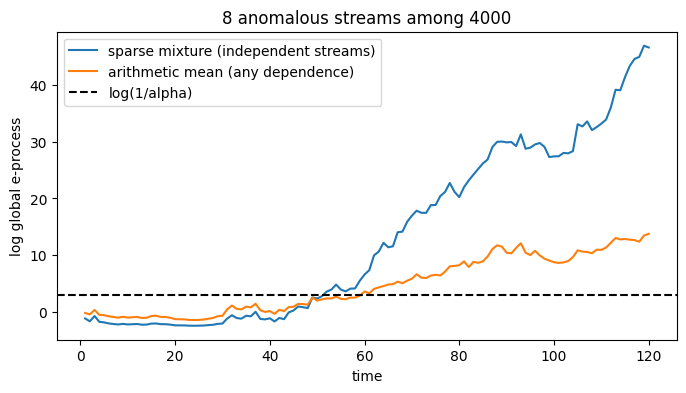

In [3]:
cum_sparse = np.maximum.accumulate(log_sparse); cum_mean = np.maximum.accumulate(log_mean)
first = next((t + 1 for t, v in enumerate(cum_sparse) if v >= np.log(1 / ALPHA)), None)
print("sparse mixture rejects the global null at t =", first, "; arithmetic mean:",
      next((t + 1 for t, v in enumerate(cum_mean) if v >= np.log(1 / ALPHA)), None))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, T + 1), log_sparse, label="sparse mixture (independent streams)")
ax.plot(range(1, T + 1), log_mean, label="arithmetic mean (any dependence)")
ax.axhline(np.log(1 / ALPHA), color="k", ls="--", label="log(1/alpha)")
ax.set_xlabel("time"); ax.set_ylabel("log global e-process"); ax.legend(); ax.set_title(f"{n_anomalous} anomalous streams among {K}")
plt.show()

**How to read the chart.** Both curves are global log-evidence over time. The sparse mixture
crosses the alarm line first and then pulls away; the arithmetic mean only follows once the eight
anomalous streams have become individually enormous. In the printout, the posterior-mean sparsity
converges towards the true 8/4000 = 0.002 and the top-10 list fills up with the true anomalous
streams — the triage list an operator would open first.

## Where detection becomes possible: the detection moment

There is a hard limit on how early *any* method can sound the alarm. Pérez-Ortiz, Castro & Stoepker
parametrise sparsity as `eps = K^-beta` and signal as `delta = sqrt(2 ln K / T*)` and prove that no
test martingale can grow before `t* = T* rho(beta)`, while the mixture rejects with probability
tending to one after it (`rho` is the Donoho–Jin detection boundary). Knowing `t*` lets an
operations team set expectations: an alarm that arrives around `t*` is as fast as physics allows.
Here `beta = 0.75`, `T* = 40`, so `t* = 10` time steps.

In [4]:
beta, T_star = 0.75, 40.0
eps = K ** (-beta); delta = np.sqrt(2 * np.log(K) / T_star); t_star = T_star * detection_boundary(beta)
print(f"eps={eps:.4f} (about {eps*K:.1f} anomalous streams), delta={delta:.3f}, detection moment t*={t_star:.0f}")

n_reps = 15
first_rejections = []
for _ in range(n_reps):
    anom = rng.random(K) < eps
    S = np.zeros(K); log_max = 0.0; hit = None
    for t in range(1, 41):
        S += rng.standard_normal(K) + delta * anom
        log_lr = delta * S - t * delta**2 / 2                  # oracle per-stream likelihood ratio
        log_max = max(log_max, sparse_merger.merge_log(log_lr).log_merged_e_value)
        if hit is None and log_max >= np.log(1 / ALPHA):
            hit = t
    first_rejections.append(hit if hit is not None else np.inf)
first_rejections = np.array(first_rejections)
print("first rejection times:", first_rejections)
print(f"rejected by t=3: {np.mean(first_rejections <= 3):.2f}   by t=40: {np.mean(first_rejections <= 40):.2f}")

eps=0.0020 (about 8.0 anomalous streams), delta=0.644, detection moment t*=10


first rejection times: [40 28 15 30 22 26 14 17 28 14 22 24 14 14 28]
rejected by t=3: 0.00   by t=40: 1.00


## More settings, same two lines of code

Each scenario below is the same pattern: per-stream e-processes from the parallel engine, the sparse
mixture for "is anything wrong?", and `e_bh` (FDR control) for "which streams?". The shift is in
units of the stream's noise standard deviation (streams are standardised residuals against their
normal behaviour, with the noise level known from history).

In [5]:
def monitor(K, anomalous_idx, shift, T, onset=1, seed=0, alpha=0.05):
    rng_ = np.random.default_rng(seed)
    engine = ParallelSequentialTest(
        config=ParallelTestConfig(n_tests=K, alpha=alpha, alternative="greater", combiner="all_in"),
        null_values=0.0, variance=1.0)
    sparse, mean = SparseMixtureMerger(K), ArithmeticMeanMerger(K)
    signal = np.zeros(K); signal[anomalous_idx] = shift
    t_sparse = t_mean = None
    log_max_s = log_max_m = 0.0
    for t in range(1, T + 1):
        engine.step(rng_.standard_normal(K) + (signal if t >= onset else 0.0))
        log_m = engine.log_e_processes()
        log_max_s = max(log_max_s, sparse.merge_log(log_m).log_merged_e_value)
        log_max_m = max(log_max_m, mean.merge(np.exp(log_m)).log_merged_e_value)
        if t_sparse is None and log_max_s >= np.log(1 / alpha): t_sparse = t
        if t_mean is None and log_max_m >= np.log(1 / alpha): t_mean = t
    bh = engine.e_bh()
    found = np.flatnonzero(bh.rejected)
    true_pos = len(set(found) & set(anomalous_idx))
    diag = sparse.diagnostics(np.exp(engine.log_e_processes()))
    print(f"K={K:6d}  anomalous={len(anomalous_idx):3d}  shift={shift}  | global alarm: sparse t={t_sparse}, mean t={t_mean}"
          f"  | e-BH found {len(found)} streams ({true_pos} true, {len(found) - true_pos} false)"
          f"  | top-10 hits {len(set(diag.top_streams) & set(anomalous_idx))}/10")

**Neuroimaging.** 20,000 voxels, a small activated cluster of 25 voxels with a weak effect. The
question "is there *any* activation in this region?" is answered by the sparse mixture; the cluster
itself is then localised by e-BH and the top-stream list.

In [6]:
rng_local = np.random.default_rng(1)
monitor(K=20000, anomalous_idx=rng_local.choice(20000, 25, replace=False), shift=0.4, T=80, seed=1)

K= 20000  anomalous= 25  shift=0.4  | global alarm: sparse t=60, mean t=60  | e-BH found 0 streams (0 true, 0 false)  | top-10 hits 9/10


**MLOps: feature drift.** 2,000 input features of a deployed model are monitored as standardised
drift statistics. Five features start drifting at time 20 (a data-pipeline change). The anomaly
starts late, so detection is slower than in the from-the-start model — but still comes.

In [7]:
monitor(K=2000, anomalous_idx=np.array([17, 404, 999, 1200, 1777]), shift=0.6, T=80, onset=20, seed=2)

K=  2000  anomalous=  5  shift=0.6  | global alarm: sparse t=73, mean t=64  | e-BH found 2 streams (2 true, 0 false)  | top-10 hits 5/10


**Supply chain: SKU demand anomalies.** 1,500 SKUs with standardised forecast residuals. Twelve
SKUs deviate (a promotion leak, a stock-out pattern). One alarm for the planner, then the SKU list.

In [8]:
monitor(K=1500, anomalous_idx=np.arange(0, 1500, 125), shift=0.5, T=60, seed=3)

K=  1500  anomalous= 12  shift=0.5  | global alarm: sparse t=25, mean t=24  | e-BH found 3 streams (3 true, 0 false)  | top-10 hits 7/10


**LLM operations: prompt-cluster quality.** 5,000 prompt clusters each have a standardised
quality-score stream (judge score minus its historical mean, over noise). Six clusters degrade after
a model or retrieval change. The sparse mixture is the "did anything regress?" pager; e-BH lists the
clusters to inspect.

In [9]:
monitor(K=5000, anomalous_idx=np.array([3, 900, 1500, 2600, 3333, 4999]), shift=0.5, T=70, seed=4)

K=  5000  anomalous=  6  shift=0.5  | global alarm: sparse t=None, mean t=66  | e-BH found 1 streams (1 true, 0 false)  | top-10 hits 6/10


**Clinical safety surveillance.** 3,000 hospital units report standardised excess adverse-event
rates every week; four units have a genuine problem. A single system-level alarm with a controlled
false-alarm rate replaces thousands of noisy unit-level thresholds.

In [10]:
monitor(K=3000, anomalous_idx=np.array([10, 700, 1900, 2950]), shift=0.7, T=60, seed=5)

K=  3000  anomalous=  4  shift=0.7  | global alarm: sparse t=49, mean t=47  | e-BH found 1 streams (1 true, 0 false)  | top-10 hits 4/10


**How to read the printout.** Over 15 simulated systems, none was flagged before `t = 3` (well
before the detection moment `t* = 10`) and essentially all were flagged well within the horizon —
the theory's dichotomy shows up at K = 4000, not only in the limit.

## Where to use this

* **Fraud and payments**: thousands of merchant or card-cohort risk rates; one alarm when a small
  cluster starts drifting, plus a triage list of the likely cohorts.
* **Observability / SRE**: thousands of service KPIs; a single "something is wrong" pager with a
  controlled false-alarm rate, instead of thousands of noisy per-metric alerts.
* **Manufacturing and IoT**: sensor fleets where a few units degrade.
* **Clinical and genomics**: many endpoints or genes, few true effects — the classic sparse regime.
* **Neuroimaging**: hundreds of thousands of voxels with sparse activation (the engine scales to that).

Requirement to remember: the streams must be independent for the sparse mixture; otherwise use the
arithmetic-mean merge, which is valid under any dependence but weaker.